# 04 — Post-Regain Metrics (Inter Miami 2023)

Loads persisted artifacts from `data/marts/` and `docs/figures/`. Does not recompute.

Scope: 6 Inter Miami matches in StatsBomb Open Data. 353 regains detected. No other MLS teams have event-level coverage in Open Data — see `docs/data_reality.md` §1.

All figure interpretations use associational language only (spec §9).

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
MARTS = ROOT / "data" / "marts"
FIG = ROOT / "docs" / "figures"

team_table = pd.read_csv(MARTS / "team_post_regain.csv")
baseline = pd.read_csv(MARTS / "asa_mls_2023_baseline.csv")

team_table

,metric,point_estimate,ci_lo,ci_hi,n_regains
0,xg_per_regain,0.008271,0.004397,0.013506,353
1,time_to_shot_median,5.500000,4.000000,9.000000,353
2,rushed_shot_rate,0.352941,0.136364,0.484907,353
3,regain_to_final_third_rate,0.668555,0.567797,0.772196,353
4,regain_to_loss_rate,0.011331,0.002710,0.024465,353
5,patience_composite,-10.878091,-11.317429,-10.284371,353


In [2]:
baseline

,metric,league_mean,league_std,n_teams,source_endpoint,note
0,xg_per_shot,0.104185,0.008817,29,teams/xgoals,"xgoals_for / shots_for per team, MLS 2023. Use..."
1,rushed_shot_rate,NaN,NaN,0,teams/xgoals,ASA team-season aggregates do not expose time-...


## 1. Six metrics with 95% bootstrap CIs

Match-resampled (1000 iterations). Violet bars; gray dashed line = ASA MLS 2023 league-mean xG/shot for dimensional reference.

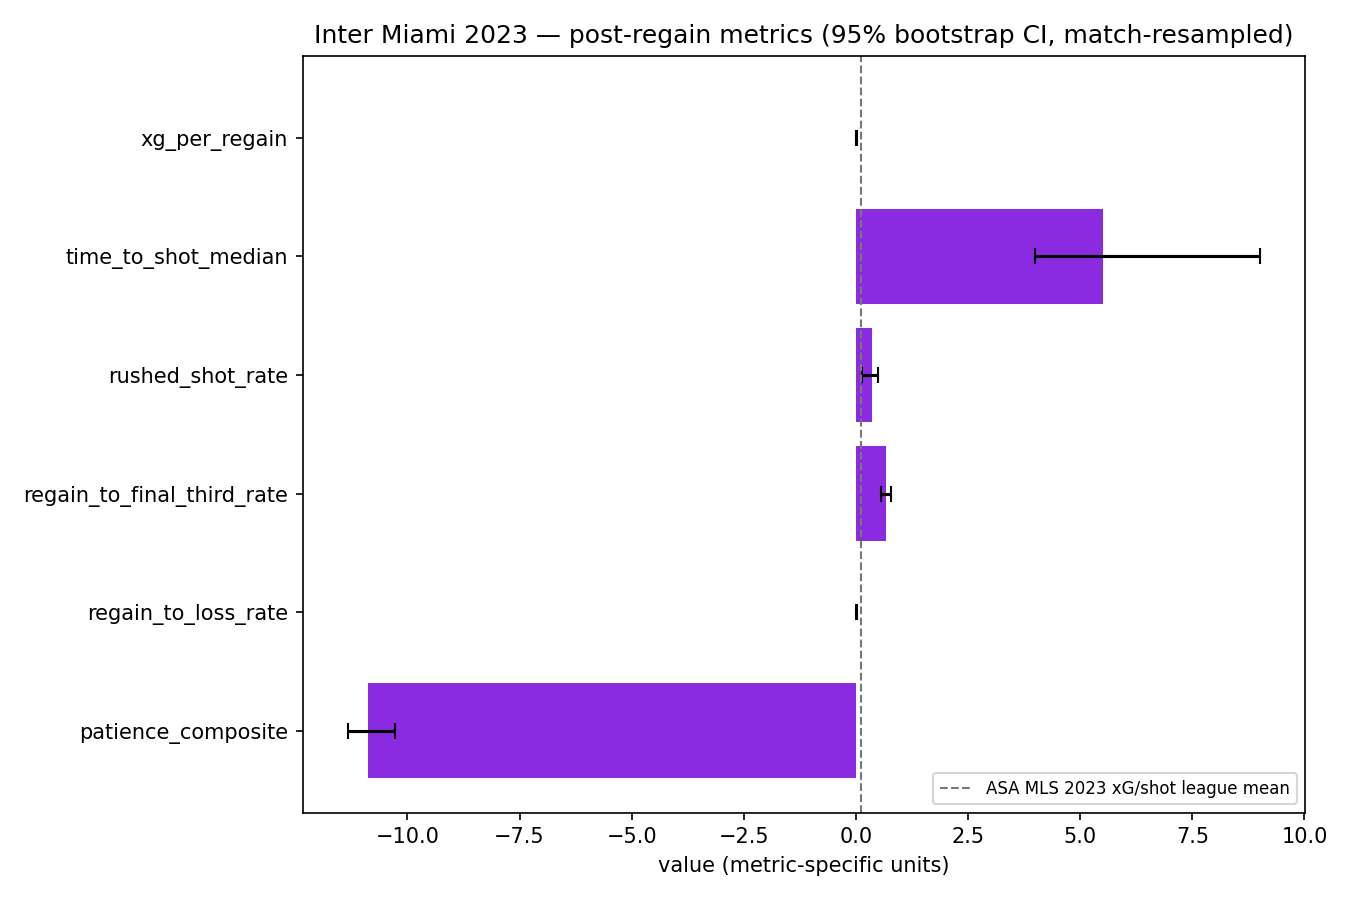

In [3]:
display(Image(str(FIG / "post_regain_metrics_bar.png")))

**Interpretation.** Inter Miami converts **about 10% of regains** (34 of 353) **into a shot within 15 seconds**, while **final-third entry** occurs on **roughly two-thirds** of regains (point estimate ≈0.67, bootstrap CI ≈0.57–0.77). **xG per regain** sits near **0.008** (CI above zero but small). The gray dashed reference is **ASA MLS 2023 mean xG per shot (~0.10)** — useful scale context for **shot efficiency**, not a direct regain benchmark. Among early-window shots, **rushed-shot share is ~0.35**, **median time-to-shot ~5.5 s**. **`patience_composite`** stays strongly negative when scored against that league line; treat **rank and sign** as descriptive. **Wide CIs** coincide with **n = 6 matches**.

## 2. Regain-outcome flow (Sankey)

Each regain flows into one of: shot within 15s, final-third entry without shot, possession lost within 4 actions, or other.

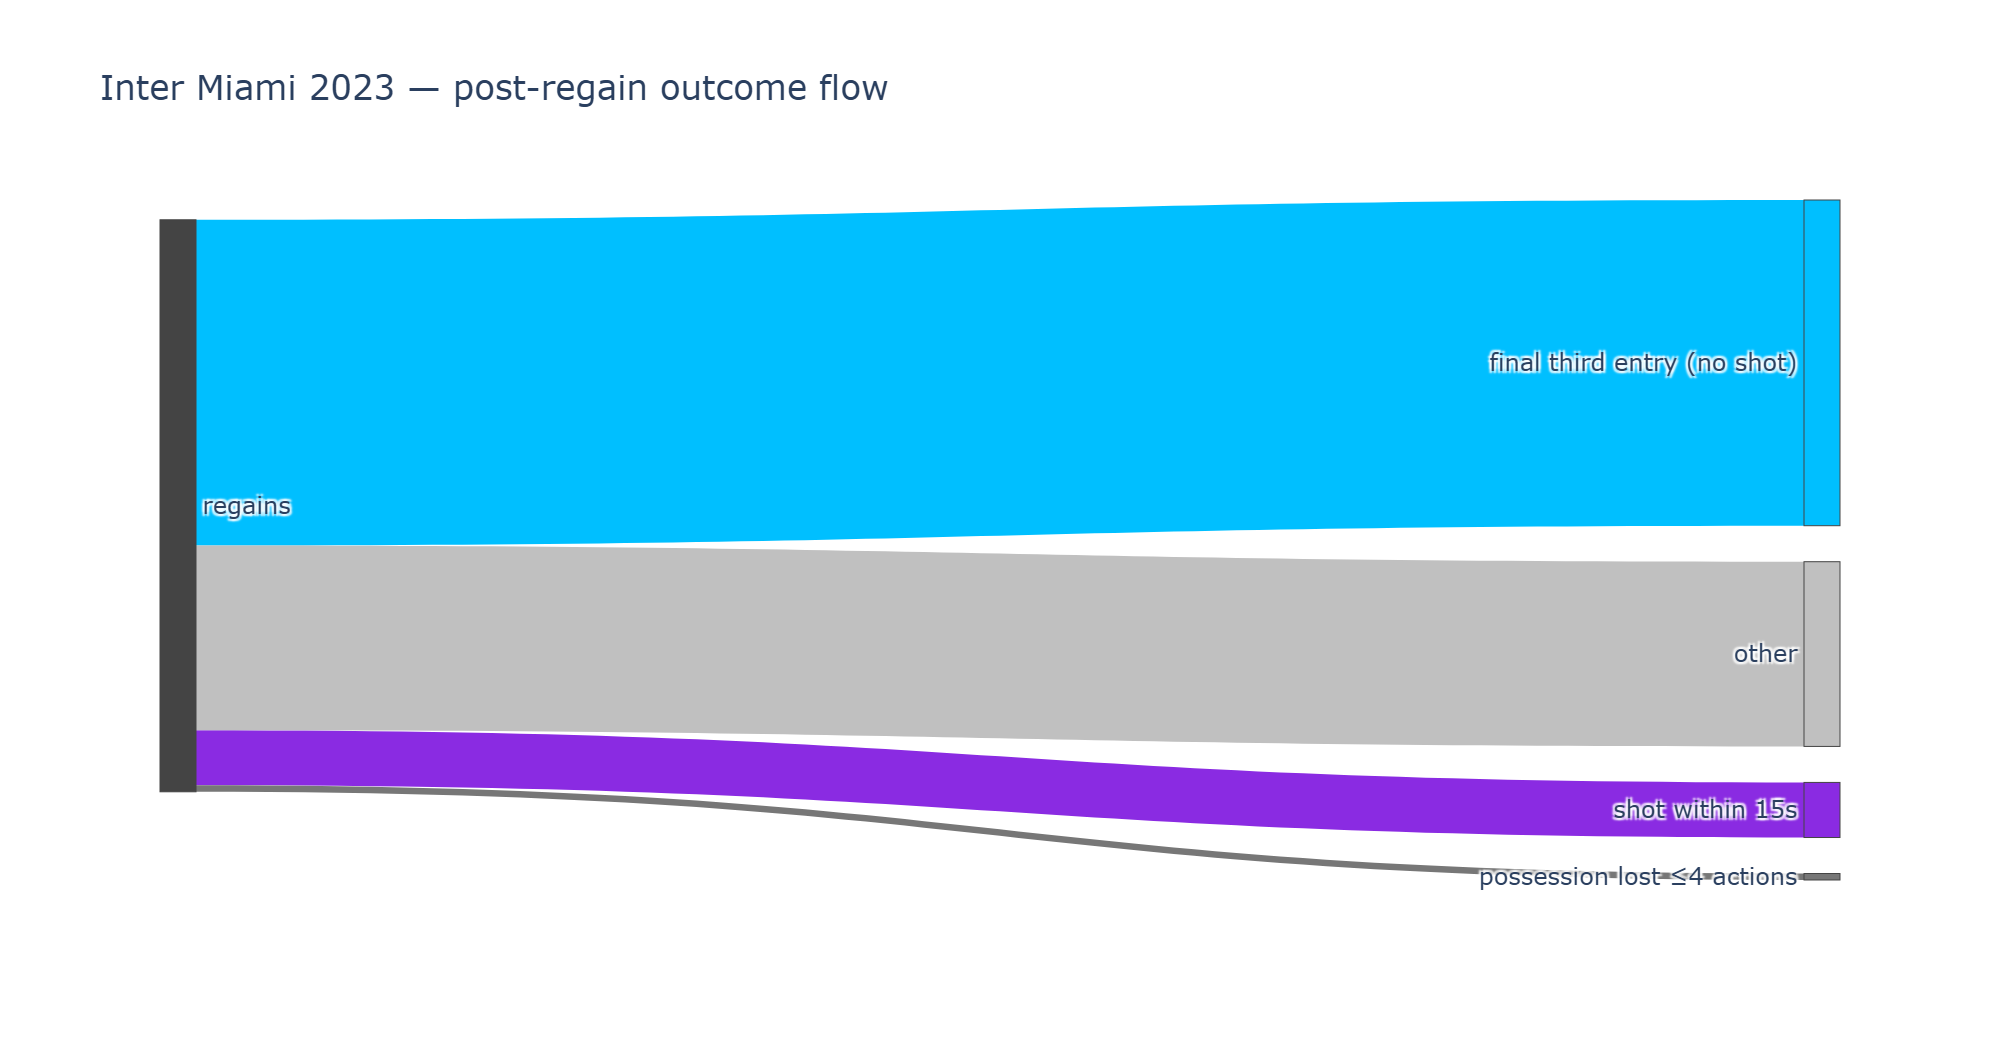

In [4]:
display(Image(str(FIG / "post_regain_sankey.png")))

**Interpretation.** The **modal path is final-third entry without a shot within 15 s (~57% of regains)**; the **second-largest bucket is “other” (~32%)** — longer dwells, stoppages, fouls won, or routes outside the simple four-action loss rule. **Shots within 15 s sit near ~10%**, and **loss within four actions ~1%**. Together, that split supports the project’s **post-regain waste** framing on this corpus: **most ball-wins neither become an immediate shot nor read as rapid turnover**. Proportions are **associational** summaries for **Inter Miami over six Open Data matches**; **ASA** supplies **league-season context elsewhere**, not a regain-outcome baseline for this diagram.

## 3. Time-to-shot distribution

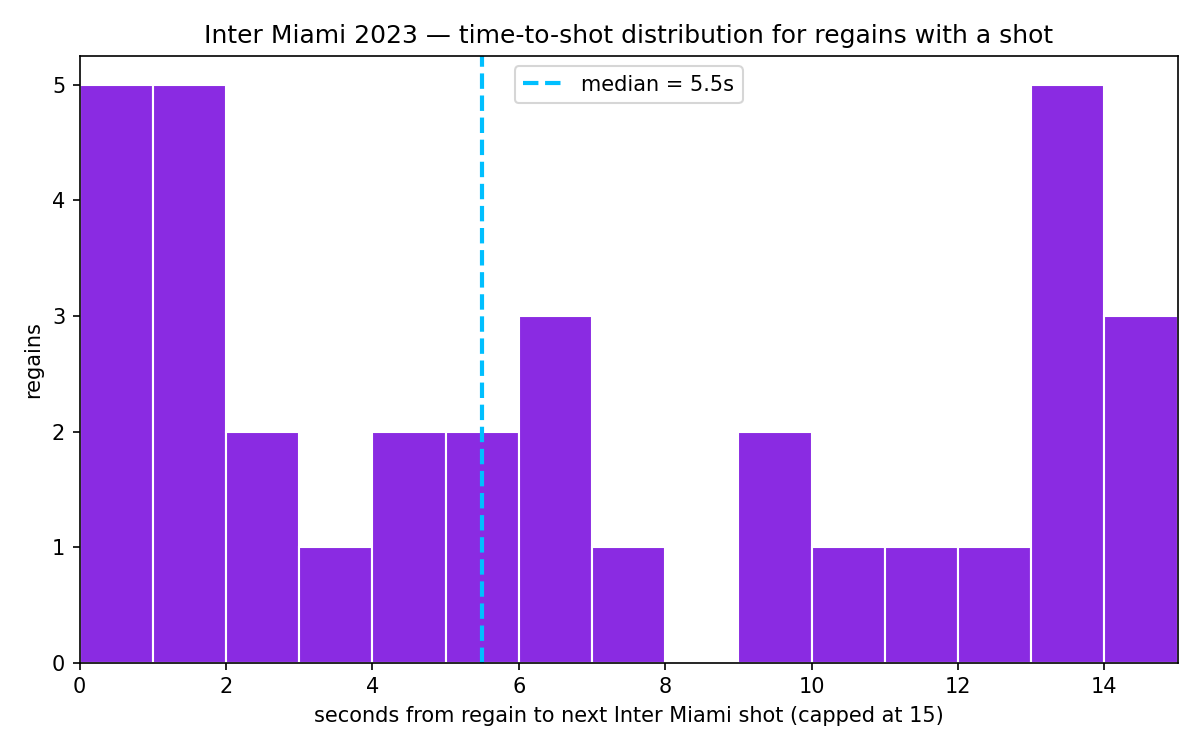

In [5]:
display(Image(str(FIG / "time_to_shot_hist.png")))

**Interpretation.** When a shot lands inside the **15 s** window, **timing stacks toward the first seconds** (**median ~5.5 s** per the team table). A **secondary lump near ~10–14 s** coincides with **slower progresses or a reset before the attempt** — still **team-level tempo**, not individual attribution. No **MLS-wide regain-to-shot time distribution** exists in this Open Data slice, so **ASA league baselines** stay **outside** this histogram. Read it as **how Inter Miami times rare early shots after regains**, not proof of deviation from an unspecified league norm.

## 4. Regain location hexbin

Inter Miami attacking right; x = 0 own goal, x = 120 opponent goal. Dashed lines at x = 40 and x = 80 mark thirds.

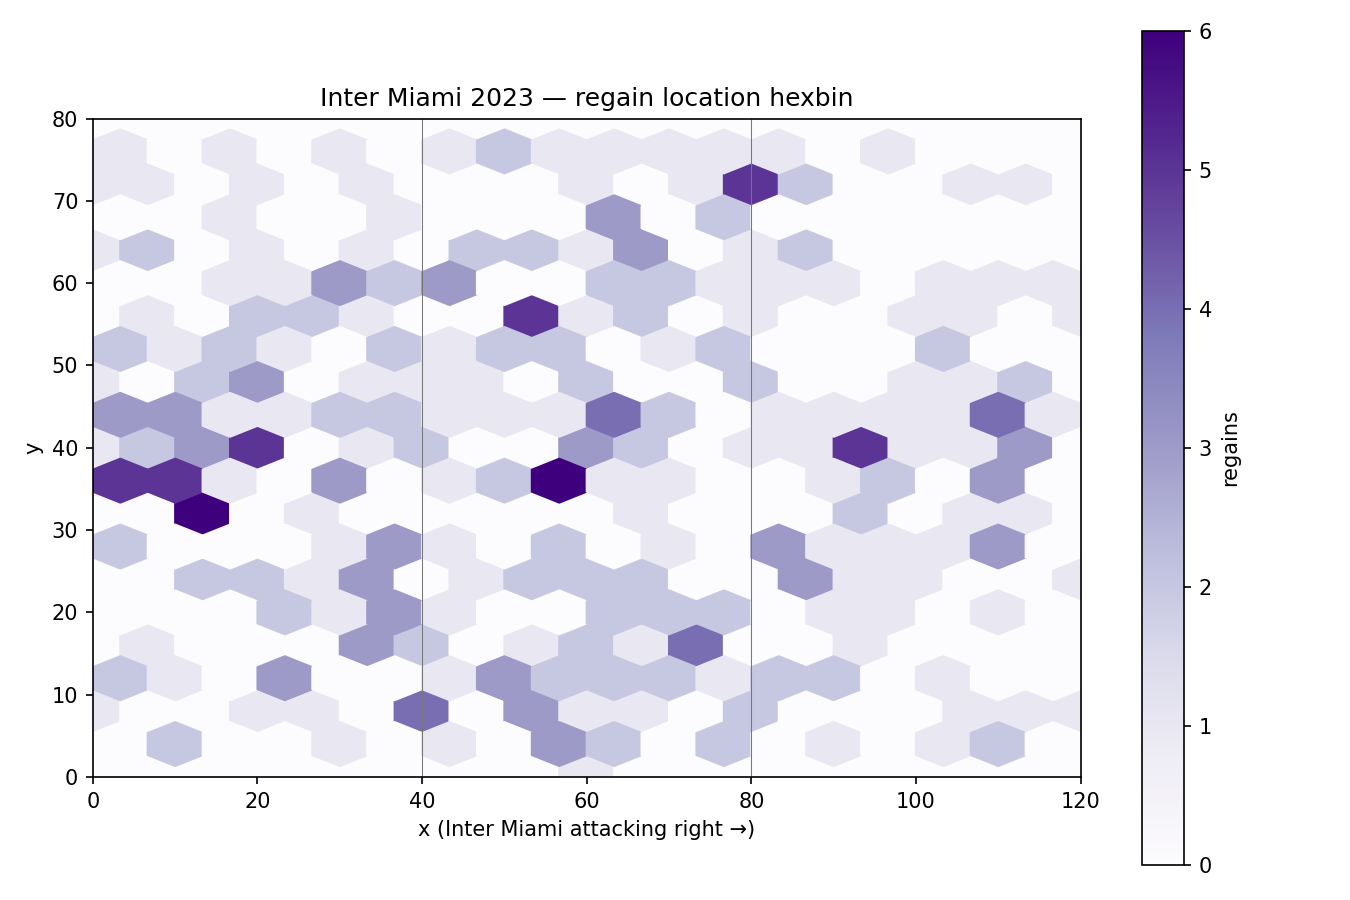

In [6]:
display(Image(str(FIG / "regain_zones_heatmap.png")))

**Interpretation.** **Regain volume skews deeper**: **middle third ~39%**, **defensive third ~36%**, **attacking third ~26%** — consistent with **more ball-wins in own half than in the final press lane**, **team-level shape** rather than line-by-line assignments. **Wide lateral spread** coincides with **compact-block recoveries** across channels. **ASA** can frame **season-level league pace or chance quality**, not **where regains occur on the pitch**. For **Leverkusen pre/post (Module C)**, the **associational contrast** is **where regain mass sits** **before vs. after** the pivot — **not** a verdict on **Inter Miami’s** defensive merit **in isolation**.

## Inter Miami 2023 — post-regain profile

On **353 regains** across **six** Open Data matches, the team-level pattern is **low immediate threat per ball won** alongside **frequent forward progress**: **xG per regain** is small in absolute terms, while **final-third entry** happens on a **clear majority of regains**; **shots inside 15 seconds** occur on **roughly one in ten** sequences. Against **ASA MLS 2023** summaries, treat **mean xG per shot** (~0.10 at league level in this mart) as **orthogonal scale context** for bars that reference shot efficiency — **not** an apples-to-apples regain comparator. Interpretations stay **associational**: they describe **what coincided** with these recoveries in **this truncated MLS sample**, not mechanisms inside any one player.

The **Sankey decomposition** aligns with **post-regain waste** read as **volume that never becomes an early shot**: the **modal outcome is final-third entry without a shot under the 15 s rule**, followed by **a large “other” residue** spanning longer possessions and edge cases outside the tidy loss-within-four-actions lane. Together with **regain-zone heat**, the portrait is **mid-/deep-block recoveries** and **territorial gains that often stall short of immediate chance creation**. Reserve **cross-team MLS claims** until **coverage expands**; Phase 8 language should **stress scope** and pair these numbers with **ASA league context only where dimensional match is explicit**.